In [1]:
from PIL import Image
import numpy as np
import glob

all_images = []
all_labels = []
filenames = []
ages = []
img_size = (80,100)
for f in glob.glob('c:\\data\\xray\\**\\*.jpg', recursive=True):
    arr = f.split('\\')
    arr2 = arr[3].split('_')
    if arr2[1] == 'M':
        img = Image.open(f)
        filenames.append(arr[-1])
        img_resize = img.resize((img_size[0], img_size[1]))
        all_images.append(img_resize)
        age = int(arr2[2].replace('yr',''))
        ages.append(age)

In [2]:
filenames[:10]

['332_M.jpg',
 '333_M.jpg',
 '334_M.jpg',
 '335_M.jpg',
 '336_M.jpg',
 '337_M.jpg',
 '338_M.jpg',
 '339_M.jpg',
 '340_M.jpg',
 '341_M.jpg']

In [3]:
items = list(zip(filenames, ages, all_images))
items[:10]

[('332_M.jpg', 10, <PIL.Image.Image image mode=RGB size=80x100>),
 ('333_M.jpg', 10, <PIL.Image.Image image mode=RGB size=80x100>),
 ('334_M.jpg', 10, <PIL.Image.Image image mode=RGB size=80x100>),
 ('335_M.jpg', 10, <PIL.Image.Image image mode=RGB size=80x100>),
 ('336_M.jpg', 10, <PIL.Image.Image image mode=RGB size=80x100>),
 ('337_M.jpg', 10, <PIL.Image.Image image mode=RGB size=80x100>),
 ('338_M.jpg', 10, <PIL.Image.Image image mode=RGB size=80x100>),
 ('339_M.jpg', 10, <PIL.Image.Image image mode=RGB size=80x100>),
 ('340_M.jpg', 10, <PIL.Image.Image image mode=RGB size=80x100>),
 ('341_M.jpg', 10, <PIL.Image.Image image mode=RGB size=80x100>)]

In [4]:
len(all_images)

665

In [5]:
np.array(all_images[0]).shape

(100, 80, 3)

In [6]:
X = np.empty((1, img_size[0], img_size[1], 3))
for img in all_images:
    X = np.vstack((X, np.array(img).reshape(1, img_size[0], img_size[1], 3)))
X.shape

(666, 80, 100, 3)

In [7]:
X = np.delete(X, (0), axis=0)

In [8]:
X.shape

(665, 80, 100, 3)

In [9]:
y = np.array(ages)
y[:10]

array([10, 10, 10, 10, 10, 10, 10, 10, 10, 10])

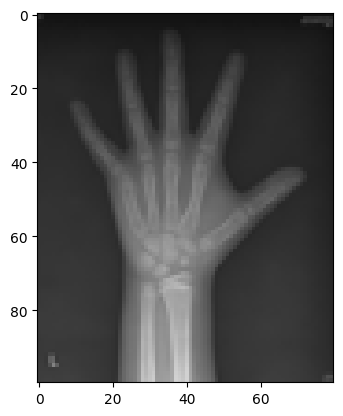

In [10]:
import matplotlib.pyplot as plt
plt.imshow(all_images[0])
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, stratify = y, shuffle = True, random_state = 10)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((532, 80, 100, 3), (133, 80, 100, 3), (532,), (133,))

In [12]:
import pandas as pd
pd.DataFrame(y_train).value_counts()

0 
4     40
5     40
6     40
8     40
7     40
9     40
10    40
14    40
11    40
12    40
13    40
15    36
3     25
16    24
17     7
Name: count, dtype: int64

In [13]:
X_train = X_train.reshape(-1, img_size[0] * img_size[1] * 3)
X_test = X_test.reshape(-1, img_size[0] * img_size[1] * 3)

In [14]:
X_train = X_train /255.
X_test = X_test /255.

In [15]:
X_train = X_train.reshape(-1, img_size[0], img_size[1], 3)
X_test = X_test.reshape(-1, img_size[0], img_size[1], 3)

In [16]:
y_train_backup = y_train
y_test_backup = y_test

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

model = Sequential()
model.add(Conv2D(64, (3,3), padding='same', input_shape=X_train.shape[1:], activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mae', metrics=['mae'])
model.summary()

C:\python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 80, 100, 64)    │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 40, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 38, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 19, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 17, 22, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 23936)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,531,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,607,681 (6.13 MB)

 Trainable params: 1,607,681 (6.13 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((532, 80, 100, 3), (133, 80, 100, 3), (532,), (133,))

In [19]:
from tensorflow.keras.callbacks import ModelCheckpoint
#실험과정에서 최적의 성능을 낸 모델을 저장 (validation 오차 기준 최소값일 때 저장)
checkpoint = ModelCheckpoint('c:/data/models/xray_m_best.keras', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
hist = model.fit(X_train, y_train, batch_size=32, validation_split=0.2, epochs=30, callbacks=[checkpoint])

Epoch 1/30
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 5.5334 - mae: 5.5334
Epoch 1: val_loss improved from None to 3.17368, saving model to c:/data/models/xray_m_best.keras

Epoch 1: finished saving model to c:/data/models/xray_m_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 4.2619 - mae: 4.2619 - val_loss: 3.1737 - val_mae: 3.1737
Epoch 2/30
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 3.1837 - mae: 3.1837
Epoch 2: val_loss did not improve from 3.17368
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 3.0885 - mae: 3.0885 - val_loss: 3.2439 - val_mae: 3.2439
Epoch 3/30
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 3.2834 - mae: 3.2834
Epoch 3: val_loss improved from 3.17368 to 3.13778, saving model to c:/data/models/xray_m_best.keras

Epoch 3: finished saving model to c:/data/models/xray_m_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 3.1735 - mae: 3.1735 - val_loss: 3.1378 - val_mae: 3.1378
Epoch 4/30
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 3

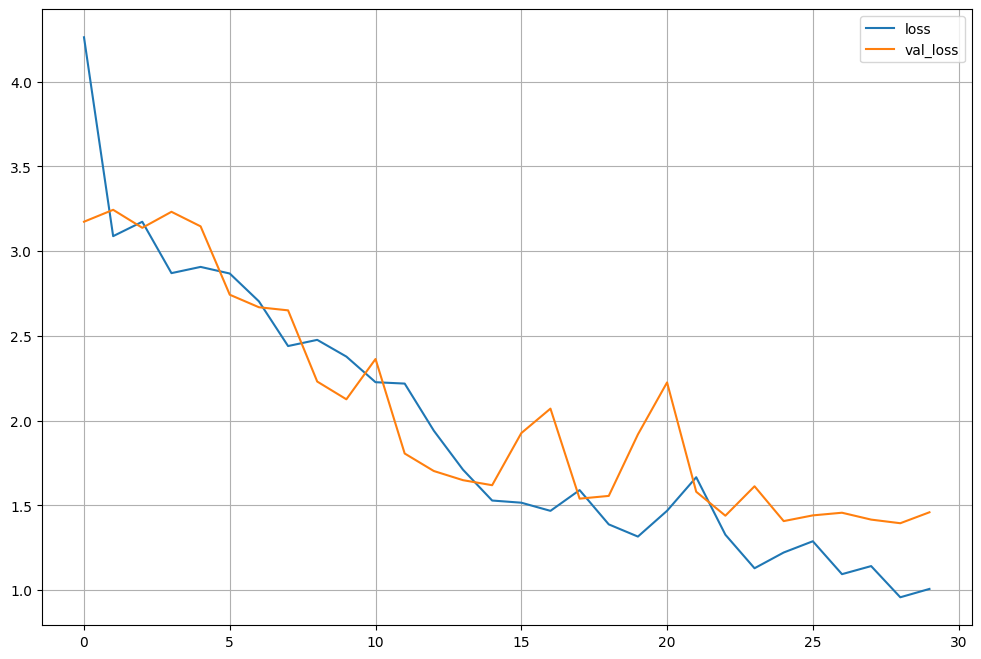

In [20]:
plt.figure(figsize=(12,8))
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.grid()
plt.show()

In [21]:
from tensorflow.keras.models import load_model

model = load_model('c:/data/models/xray_m_best.keras')
scores = model.evaluate(X_train, y_train, verbose=1)
print(scores)

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.9311 - mae: 0.9311
[0.9311317801475525, 0.9311317801475525]


In [22]:
model = load_model('c:/data/models/xray_m_best.keras')
scores = model.evaluate(X_test, y_test, verbose=1)
print(scores)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.5398 - mae: 1.5398
[1.5397533178329468, 1.5397533178329468]


In [23]:
pred = model.predict(X_test)
pred[:5]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


array([[11.047835],
       [ 7.314532],
       [12.504472],
       [12.631426],
       [ 3.006726]], dtype=float32)

In [24]:
y_test[:5]

array([10,  9, 13, 11,  5])